# GRIP Regression

In [1]:
# ------------------------------------------
# INITIATION: PYTHON AND DISPLAY
# ------------------------------------------

# Import libraries
import pandas as pd  # for data manipulation and analysis (DataFrames)
import numpy as np  # for numerical operations and arrays
import ipywidgets as widgets  # for interactive Jupyter controls (sliders, dropdowns)
import matplotlib.pyplot as plt  # for basic charts and plots
import seaborn as sns  # for advanced and prettier statistical charts
import statsmodels.api as sm  # for econometric and statistical modelling (OLS, logit, etc.)
from sklearn.preprocessing import StandardScaler  # to normalise or standardise numeric variables
from openpyxl import load_workbook  # to edit existing Excel files instead of overwriting them

from statsmodels.stats.outliers_influence import variance_inflation_factor  # to test multicollinearity (VIF)
from scipy.stats import shapiro, jarque_bera  # for normality tests (Shapiro–Wilk, Jarque–Bera)

import re  # regular expressions: used here to detect numeric prefixes (e.g. "0. Stressed") in category labels
from statsmodels.miscmodels.ordinal_model import OrderedModel  # runs the Ordered Logit / Probit regression for ordinal dependent variables

# For better visibility
from IPython.display import display, HTML  # to display styled DataFrames and HTML in notebooks

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))  # keeps long text (like variable names) from wrapping in output cells

# Set the option to display all columns
pd.set_option('display.max_columns', None)  # ensures full visibility of wide tables

# Set the option to display all rows
pd.set_option('display.max_rows', None)  # allows showing full datasets (careful with large ones)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))  
# makes numbers look like continental European formatting: 12 345,67 instead of 12,345.67

In [2]:
INPUT_FILE = "Data_stat_2019-2024.parquet"
OUTPUT_XLSX = "Data_reg_2019-2023.xlsx"


df = pd.read_parquet(INPUT_FILE)


# ------------------------------------------
# VARIABLE MANAGEMENT TEMPLATE
# ------------------------------------------

# 3. Build filtered dataset for modeling
df_model = df.copy()

df_model = df_model[
    (df_model['year'] == 2023) &
    (df_model['rank_2019'] > 0)
]

# Print the number of rows and columns
print(f"Number of rows and columns: {df_model.shape}")

Number of rows and columns: (1831, 85)


In [3]:
# ------------------------------------------
# VARIABLES SET-UP
# ------------------------------------------

import numpy as np

# STEP 2: DEFINE VARIABLES

target_var = 'ln_sales_growth_2019_2023'

# Log growth of sales using log(1+x).
# log1p allows zero values; clip(lower=0) prevents negative sales from breaking the log.
df_model[target_var] = (
    np.log1p(df_model['sales'].clip(lower=0)) -
    np.log1p(df_model['starting_sales'].clip(lower=0))
)

numeric_features = [
    'starting_ln_sales',
    'starting_capital_ratio',
    'starting_profit_margin',
    'starting_export_ratio'
]

categorical_vars = [
    'owner',
    'sector',
    'HGX23'
]

# STEP 3: DROP MISSING VALUES (WITH COPY)
all_vars = numeric_features + categorical_vars + [target_var]

before_drop = df_model["company"].tolist()

df_clean = df_model.dropna(subset=all_vars).copy()

num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].replace([np.inf, -np.inf], np.nan)

df_clean = df_clean.dropna(subset=all_vars).copy()

after_drop = df_clean["company"].tolist()

dropped_companies = set(before_drop) - set(after_drop)
dropped_count = len(dropped_companies)

print(f"\nCompanies dropped due to missing values (Total: {dropped_count}):\n")
print("\n".join(sorted(dropped_companies)))

df_clean.to_excel(OUTPUT_XLSX, index=False)


Companies dropped due to missing values (Total: 9):

EPAM Systems (Poland) sp. z o.o., Warszawa
Exertis Supply Chain Services Limited sp. z o.o. Oddział w Polsce
Global Business Travel Poland SA, Warszawa
Grupa Muszkieterów (Intermarché, Bricomarché), Swadzim
HUAWEI Polska sp. z o.o., Warszawa
Intermeble sp. z o.o. sp.k., Poznań
KPMG sp. z o.o. GK, Warszawa 
PSH Lewiatan GK, Włocławek
PwC sp. z o.o. GK, Warszawa 


In [4]:
# ------------------------------------------
# STEP 4: OUTLIER HANDLING (TARGET + FEATURES)
# ------------------------------------------

# 4.1 CONFIGURATION

# Target (dependent variable)
target_outlier_method   = 'winsor'   # 'winsor', 'trim', or 'none'
target_percentile       = 0.025

# Independent variables (numeric_features)
feature_outlier_method  = 'none'   # 'winsor', 'trim', or 'none'
feature_percentile      = 0.025


# 4.2 FUNCTION

def apply_outlier_handling(df, column, method='winsor', percentile=0.05):
    """
    Handles outliers in one column using 'winsor', 'trim', or 'none'.

    Returns:
        df_out: modified DataFrame
        col_name: name of the column to use in the model
                  (original or '_win' version)
    """
    df_out = df.copy()

    if method == 'none':
        # Do nothing
        return df_out, column

    lower = df_out[column].quantile(percentile)
    upper = df_out[column].quantile(1 - percentile)

    if method == 'winsor':
        flag_col = f"{column}_was_winsorized"
        win_col  = f"{column}_win"

        df_out[flag_col] = (df_out[column] < lower) | (df_out[column] > upper)
        df_out[win_col]  = np.clip(df_out[column], lower, upper)

        return df_out, win_col

    elif method == 'trim':
        # Keep only observations inside [lower, upper]
        df_trimmed = df_out[(df_out[column] >= lower) & (df_out[column] <= upper)].copy()
        return df_trimmed, column

    else:
        raise ValueError("Method must be 'winsor', 'trim', or 'none'")


# 4.3 APPLY TO TARGET VARIABLE

df_clean, target_variable = apply_outlier_handling(
    df_clean,
    target_var,
    method=target_outlier_method,
    percentile=target_percentile
)

print("\n--- TARGET OUTLIER HANDLING ---")
print(f"Method: {target_outlier_method.upper()} | Percentile: {target_percentile}")

if target_outlier_method == 'winsor':
    # Describe winsorised target
    print(df_clean[target_variable].describe(
        percentiles=[target_percentile, 0.25, 0.5, 0.75, 1 - target_percentile]
    ))

    flag_col = f"{target_var}_was_winsorized"
    if flag_col in df_clean.columns:
        winsorized_count = df_clean[flag_col].sum()
        print(f"\nTotal number of companies winsorised in TARGET: {winsorized_count}\n")

elif target_outlier_method == 'trim':
    print(f"Total number of companies after trimming TARGET: {df_clean.shape[0]}\n")

else:  # 'none'
    print("Target not modified (no outlier handling applied).\n")


# 4.4 APPLY TO NUMERIC FEATURES

print("--- NUMERIC FEATURES OUTLIER HANDLING ---")
print(f"Method: {feature_outlier_method.upper()} | Percentile: {feature_percentile}")

new_numeric_features = []

if feature_outlier_method in ['winsor', 'trim']:
    for col in numeric_features:
        df_clean, new_col = apply_outlier_handling(
            df_clean,
            col,
            method=feature_outlier_method,
            percentile=feature_percentile
        )
        new_numeric_features.append(new_col)

        if feature_outlier_method == 'winsor':
            flag_col = f"{col}_was_winsorized"
            if flag_col in df_clean.columns:
                winsorized_count = df_clean[flag_col].sum()
                print(f"{col}: winsorised observations = {winsorized_count}")
        else:
            # trim: report new sample size after each variable (optional)
            print(f"{col}: current number of companies after trimming = {df_clean.shape[0]}")

    # Replace the list so regression automatically uses the modified columns
    numeric_features = new_numeric_features

else:  # 'none'
    print("Numeric features not modified (no outlier handling applied).")

print("\nNumeric features used in the model:")
print(numeric_features)
print(f"\nTarget variable used in the model: {target_variable}\n")


--- TARGET OUTLIER HANDLING ---
Method: WINSOR | Percentile: 0.025
count   1 822,00
mean        0,30
std         0,40
min        -1,05
2.5%       -1,05
25%         0,13
50%         0,32
75%         0,51
97.5%       1,09
max         1,10
Name: ln_sales_growth_2019_2023_win, dtype: float64

Total number of companies winsorised in TARGET: 92

--- NUMERIC FEATURES OUTLIER HANDLING ---
Method: NONE | Percentile: 0.025
Numeric features not modified (no outlier handling applied).

Numeric features used in the model:
['starting_ln_sales', 'starting_capital_ratio', 'starting_profit_margin', 'starting_export_ratio']

Target variable used in the model: ln_sales_growth_2019_2023_win




✅ Available Dummy Variables:
Index(['owner_Foreign', 'sector_chemia', 'sector_energetyka',
       'sector_górnictwo i hutnictwo', 'sector_handel detaliczny',
       'sector_handel hurtowy', 'sector_media, telekomunkacja, IT',
       'sector_motoryzacja', 'sector_ochrona zdrowia i farmacja',
       'sector_paliwa', 'sector_produkcja', 'sector_transport',
       'sector_usługi', 'sector_żywność', 'HGX23_Increased Export Intensity'],
      dtype='object')


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     ln_sales_growth_2019_2023_win   R-squared:                       0.077
Model:                                       OLS   Adj. R-squared:                  0.067
Method:                            Least Squares   F-statistic:                     7.900
Date:                           Thu, 12 Mar 2026   Prob (F-statistic):           2.15e-21
Time:                                   14:49:52   Log-Likelihood:                -840.30
No. Observations:                           1822   AIC:                             1721.
Df Residuals:                               1802   BIC:                             1831.
Df Model:                                     19                                         
Covariance Type:                       nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 0.2264      0.029      7.933      0.000       0.170       0.282
starting_ln_sales                     0.0281      0.009      3.010      0.003       0.010       0.046
starting_capital_ratio                0.0219      0.010      2.104      0.036       0.001       0.042
starting_profit_margin                0.0411      0.010      3.931      0.000       0.021       0.062
starting_export_ratio                -0.0224      0.010     -2.232      0.026      -0.042      -0.003
owner_Foreign                        -0.0436      0.019     -2.281      0.023      -0.081      -0.006
sector_chemia                         0.0144      0.059      0.246      0.806      -0.101       0.130
sector_energetyka                     0.4522      0.076      5.960      0.000       0.303       0.601
sector_górnictwo i hutnictwo          0.0379      0.071      0.534      0.593      -0.101       0.177
sector_handel detaliczny              0.0620      0.053      1.174      0.241      -0.042       0.166
sector_handel hurtowy                -0.0229      0.039     -0.587      0.558      -0.099       0.054
sector_media, telekomunkacja, IT      0.0502      0.046      1.087      0.277      -0.040       0.141
sector_motoryzacja                    0.0730      0.038      1.904      0.057      -0.002       0.148
sector_ochrona zdrowia i farmacja     0.1097      0.051      2.161      0.031       0.010       0.209
sector_paliwa                        -0.0742      0.054     -1.369      0.171      -0.181       0.032
sector_produkcja                      0.0410      0.035      1.182      0.238      -0.027       0.109
sector_transport                      0.0670      0.047      1.430      0.153      -0.025       0.159
sector_usługi                         0.0388      0.046      0.853      0.394      -0.050       0.128
sector_żywność                        0.1682      0.038      4.382      0.000       0.093       0.244
HGX23_Increased Export Intensity      0.0879      0.019      4.704      0.000       0.051       0.124
==============================================================================
Omnibus:                      276.496   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              597.121
Skew:                          -0.884   Prob(JB):                    2.17e-130
Kurtosis:                       5.177   Cond. No.                         15.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


🔍 Shapiro-Wilk Test (normality):
  Statistic = 0.9393
  p-value   = 0.0000

📦 Jarque-Bera Test (skew + kurtosis):
  Statistic = 597.1209
  p-value   = 0.0000


,Variable,VIF
0,const,"9,97"
1,starting_ln_sales,"1,07"
2,starting_capital_ratio,"1,33"
3,starting_profit_margin,"1,34"
4,starting_export_ratio,"1,24"
5,owner_Foreign,"1,11"
6,sector_chemia,"1,23"
7,sector_energetyka,"1,14"
8,sector_górnictwo i hutnictwo,"1,16"
9,sector_handel detaliczny,"1,33"


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


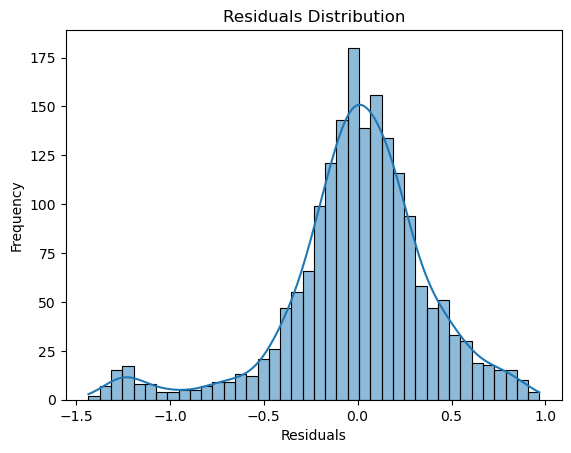

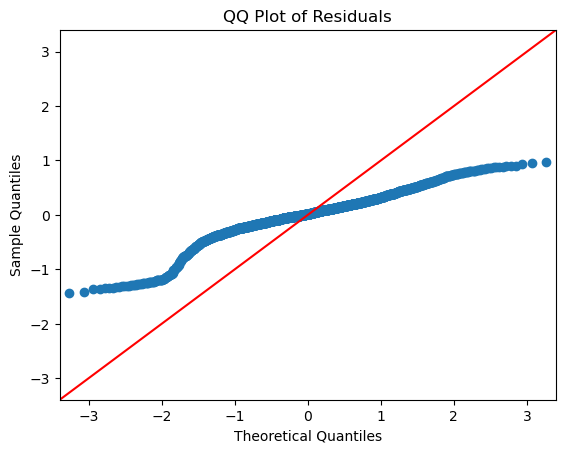

✅ Regression results successfully exported to 'Regression_OLS_Results'


In [5]:
# ------------------------------------------
# OLS REGRESSION ANALYSIS
# ------------------------------------------

# ADDITIONAL PARAMETERS
# STEP 1 - Interaction Terms
interaction_terms = [] # ('Starting_INT','Starting_Employment_ln') ('Starting_INT','Starting_Size_ln') 'HGX_Increased Export Intensity' ('Starting_INT','Foreign')

# STEP 2 - Dummy controlset-up

# OPTION A: MANUAL REFERENCE (full control)
reference_dict = {
    'owner': 'Domestic',
    'sector': 'budownictwo',
'HGX23': 'Decreased Export Intensity'} #     'HGX': 'Decreased Export Intensity',

# OPTION B: AUTOMATIC REFERENCE (first category found) – use only if needed
#reference_dict = {
#     var: df_clean[var].dropna().unique()[0] for var in categorical_vars
# }

rename_dict = {}
#    'P/F_F': 'Foreign',

# Step 2: Create all dummies
X_categorical = pd.get_dummies(df_clean[categorical_vars])

# Step 3: Drop reference dummy columns
for var, ref in reference_dict.items():
    col_to_drop = f"{var}_{ref}"
    if col_to_drop in X_categorical.columns:
        X_categorical = X_categorical.drop(columns=col_to_drop)

# Step 4: Rename columns for clarity
X_categorical = X_categorical.rename(columns=rename_dict)

# Print to verify the available dummy columns
print("\n✅ Available Dummy Variables:")
print(X_categorical.columns)

# STEP 5: STANDARDIZE NUMERIC VARIABLES
X_numeric = pd.DataFrame(
    StandardScaler().fit_transform(df_clean[numeric_features]),
    columns=numeric_features,
    index=df_clean.index
)

# STEP5 WITHOUT STANDARISATION X_numeric = df_clean[numeric_features].copy()

# STEP 5B: CLEAN COLUMN NAMES TO PREVENT HIDDEN ERRORS
X_numeric.columns = X_numeric.columns.str.strip()
X_categorical.columns = X_categorical.columns.str.strip()

# STEP 5C: DEFINE INTERACTION TERMS

interaction_terms = [(t1.strip(), t2.strip()) for t1, t2 in interaction_terms]

# STEP 5D: ADD INTERACTION TERMS WITH DIAGNOSTICS
for term1, term2 in interaction_terms:
    found_1_num = term1 in X_numeric.columns
    found_2_num = term2 in X_numeric.columns
    found_1_cat = term1 in X_categorical.columns
    found_2_cat = term2 in X_categorical.columns

    print(f"\n🔍 Trying to add interaction: {term1} * {term2}")
    print(f"  - {term1} in X_numeric: {found_1_num}")
    print(f"  - {term2} in X_numeric: {found_2_num}")
    print(f"  - {term1} in X_categorical: {found_1_cat}")
    print(f"  - {term2} in X_categorical: {found_2_cat}")

    # Get the variables
    if found_1_num:
        col1 = X_numeric[term1]
    elif found_1_cat:
        col1 = X_categorical[term1]
    else:
        print(f"⚠️ {term1} not found.")
        continue

    if found_2_num:
        col2 = X_numeric[term2]
    elif found_2_cat:
        col2 = X_categorical[term2]
    else:
        print(f"⚠️ {term2} not found.")
        continue

    # Compute interaction
    interaction_name = f"{term1}_Mult_{term2}"
    interaction_column = col1 * col2

    # Store in correct matrix
    if found_1_num and found_2_num:
        X_numeric[interaction_name] = interaction_column
        print(f"✅ Added to X_numeric: {interaction_name}")
    else:
        X_categorical[interaction_name] = interaction_column
        print(f"✅ Added to X_categorical: {interaction_name}")


# STEP 6: COMBINE FEATURES AND ADD CONSTANT
X_full = pd.concat([X_numeric, X_categorical], axis=1)
X_full = sm.add_constant(X_full).astype(float)

# STEP 7: DEFINE TARGET
y = df_clean[target_variable]

# STEP 8: FIT OLS REGRESSION MODEL
model = sm.OLS(y, X_full).fit()

# Extract coefficients as dataframe
coeff_df = pd.DataFrame({
    "Variable": model.params.index,
    "Coef": model.params.values,
    "Std Err": model.bse.values,
    "t": model.tvalues.values,
    "P>|t|": model.pvalues.values,
    "[0.025": model.conf_int()[0].values,
    "0.975]": model.conf_int()[1].values
})

# Display the full model summary
display(model.summary())

# STEP 8B: EXTRACT REGRESSION SUMMARY STATISTICS
summary_stats = {
    "Statistic": ["R-squared", "Adj. R-squared", "F-statistic", "Prob (F-statistic)", 
                  "Log-Likelihood", "AIC", "BIC", "No. Observations", "DF Residuals", "DF Model"],
    "Value": [
        model.rsquared,
        model.rsquared_adj,
        model.fvalue,
        model.f_pvalue,
        model.llf,
        model.aic,
        model.bic,
        model.nobs,
        model.df_resid,
        model.df_model
    ]
}
summary_df = pd.DataFrame(summary_stats)

# STEP 9: NORMALITY TESTS
residuals = model.resid.replace([np.inf, -np.inf], np.nan).dropna()
shapiro_test = shapiro(residuals)
jb_test = jarque_bera(residuals)

residual_stats = pd.DataFrame({
    "Test": ["Shapiro-Wilk", "Jarque-Bera"],
    "Statistic": [shapiro_test.statistic, jb_test.statistic],
    "p-value": [shapiro_test.pvalue, jb_test.pvalue]
})

print("\n🔍 Shapiro-Wilk Test (normality):")
print(f"  Statistic = {shapiro_test.statistic:.4f}")
print(f"  p-value   = {shapiro_test.pvalue:.4f}")

print("\n📦 Jarque-Bera Test (skew + kurtosis):")
print(f"  Statistic = {jb_test.statistic:.4f}")
print(f"  p-value   = {jb_test.pvalue:.4f}")

# STEP 10: CALCULATE VIF TO CHECK MULTICOLLINEARITY
vif_data = pd.DataFrame({
    "Variable": X_full.columns,
    "VIF": [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]
})
display(vif_data)

# STEP 11: RESIDUALS DISTRIBUTION PLOT
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# STEP 12: QQ PLOT
sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals")
plt.show()

from datetime import datetime

now = datetime.now()

# ---------- TARGET OUTLIER SUMMARY ----------
# Record outlier method and number of affected observations (TARGET)
if target_outlier_method == 'winsor':
    flag_col = f"{target_var}_was_winsorized"
    outlier_count = int(df_clean[flag_col].sum()) if flag_col in df_clean.columns else 0
    outlier_description = f"TARGET: WINSOR (percentile = {target_percentile})"
    outlier_note = f"{outlier_count} companies winsorised"

elif target_outlier_method == 'trim':
    original_n = df_clean_before_outliers.shape[0]
    trimmed_n  = df_clean.shape[0]
    outlier_count = original_n - trimmed_n
    outlier_description = f"TARGET: TRIM (percentile = {target_percentile})"
    outlier_note = f"{outlier_count} companies trimmed"

else:  # 'none'
    outlier_count = 0
    outlier_description = "TARGET: none"
    outlier_note = "no outlier handling on target"


# ---------- FEATURE OUTLIER SUMMARY ----------
# assumes you have numeric_features_raw with original names
if feature_outlier_method == 'winsor':
    feature_outlier_count = 0
    for col in numeric_features_raw:
        flag_col = f"{col}_was_winsorized"
        if flag_col in df_clean.columns:
            feature_outlier_count += int(df_clean[flag_col].sum())
elif feature_outlier_method == 'trim':
    original_n = df_clean_before_outliers.shape[0]
    trimmed_n  = df_clean.shape[0]
    feature_outlier_count = original_n - trimmed_n
else:  # 'none'
    feature_outlier_count = 0

feature_summary = f"{feature_outlier_method} (p={feature_percentile})"
feature_note    = f"{feature_outlier_count} observations affected"


# ---------- METADATA TABLE ----------
metadata_items = [
    ("Dep. Variable", model.model.endog_names),
    ("Model", type(model.model).__name__),
    ("Method", "Least Squares"),
    ("Date", now.strftime("%Y-%m-%d")),
    ("Time", now.strftime("%H:%M:%S")),
    ("No. Observations", model.nobs),
    ("Df Residuals", model.df_resid),
    ("Df Model", model.df_model),
    ("Covariance Type", model.cov_type),
    ("Outlier Handling", outlier_description),
    ("Affected Companies", outlier_note),
]

# Add features info
metadata_items.extend([
    ("Feature Outlier Handling", feature_summary),
    ("Feature Affected", feature_note),
])


# Convert summary stats to tuples
summary_items = list(zip(summary_df["Statistic"], summary_df["Value"]))

# Combine both into one list
combined_summary = metadata_items + summary_items

# Create DataFrame
combined_df = pd.DataFrame(combined_summary, columns=["Item", "Value"])

# EXPORT TO EXCEL
with pd.ExcelWriter("Results/Regression_OLS_Results_2023.xlsx") as writer:
    combined_df.to_excel(writer, sheet_name="Model_Summary", index=False)
    coeff_df.to_excel(writer, sheet_name="Model_Coefficients", index=False)
    vif_data.to_excel(writer, sheet_name="VIF", index=False)
    residual_stats.to_excel(writer, sheet_name="Residual_Tests", index=False)

print("✅ Regression results successfully exported to 'Regression_OLS_Results'")